# Steam Game Success Prediction

## A. Experimental Notebook

This notebook goes through experimental implementation and analysis for the
Steam Game Success Prediction project.

The experiments investigate whether structured Steam game metadata and
natural language information can be used to predict game success, and examine
the contribution of textual representations through DistilBERT-based models.

The notebook covers the experiments for **RQ1, RQ2, and RQ3**, including
baseline models, BERT-based models, fusion modelling, feature importance,
genre-specific analysis, and ablation studies.

## B. Experimental Setup

Game success is defined using the positive-review ratio, with games having a
positive-review ratio of **70% or higher** classified as successful.

The dataset is divided into **70% training, 15% validation, and 15% test**
sets using a fixed random seed of **42**.

**Primary evaluation metric:** Macro-F1

The same test set is retained throughout the experiments to enable consistent
comparison between the evaluated models.

## C. Notebook Dependencies

- **NumPy / Pandas** — data processing and feature engineering
- **Scikit-learn** — preprocessing, baseline models, and evaluation
- **LightGBM / XGBoost** — gradient-boosting models
- **PyTorch** — neural-network and fusion models
- **Transformers** — DistilBERT text embeddings
- **Matplotlib / Seaborn** — visualisation
- **SHAP** — model explainability
- **tqdm / Joblib** — progress monitoring and model persistence

Detailed environment setup, dependencies, project structure, and
reproducibility instructions are provided in `README.md`.

## D. Notebook Index

**00 Dependencies Check**

**01). Import and Confirmations**

**02). Load and Inspect Data**

**03). Feature Engineering**

**04). Train/ Val, Tespt Split (70/ 15/ 15)**

**RQ1 — Can pre-launch metadata predict commercial success?**

**05). SkLearn Baseline**

**06). Tabular NLP (PyTorch + MPS)**

**RQ2 — Does BERT text improve over metadata-only baselines?**

**07). Fusion Model (DistilBERT + MPS)**

**RQ3 — Which features are most predictive? Do they differ by genre?**

**08). SHAP Feature**

**09). Table - Final Rsult**

**10).Evaluation and Results**
- **10.1 Experimental Setup**
- **10.2 Baseline Results - Tabular Only**
- **10.3 BERT – Only Model Results**
- **10.4 Fusion Model Results**
- **10.5 Feature Importance Analysis**
- **10.6 Genre-Specific Analysis**
- **10.7 Ablation Study**
- **10.8 Discussion**

# 00). Dependencies Check 

In [1]:
import sys
import importlib
import importlib.metadata as metadata


# Libraries needed for thecproject 
REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scikit-learn": "sklearn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
    "torch": "torch",
    "transformers": "transformers",
    "tqdm": "tqdm",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
}

print("=" * 75)
print("THESIS NOTEBOOK DEPENDENCY CHECK")
print("=" * 75)

print(f"\nPython version : {sys.version.split()[0]}")
print(f"Python path    : {sys.executable}")

print("\n" + "-" * 75)
print(f"{'Package':<18} {'Installed':<12} {'Imported':<12} {'Version'}")
print("-" * 75)


# Package Check
results_check = []

for package_name, import_name in REQUIRED_PACKAGES.items():

    # Check installation
    try:
        version = metadata.version(package_name)
        installed = True
    except metadata.PackageNotFoundError:
        version = "NOT INSTALLED"
        installed = False

    imported = import_name in sys.modules

    results_check.append({
        "package": package_name,
        "installed": installed,
        "imported": imported,
        "version": version
    })

    print(
        f"{package_name:<18} "
        f"{'YES':<12} "
        f"{'YES' if imported else 'NO':<12} "
        f"{version}"
        if installed
        else
        f"{package_name:<18} "
        f"{'NO':<12} "
        f"{'NO':<12} "
        f"{version}"
    )

# Check PyTorch details
print("\n" + "-" * 75)
print("PYTORCH / MPS CHECK")
print("-" * 75)

try:

    import torch

    print(f"PyTorch version : {torch.__version__}")
    print(f"MPS available   : {torch.backends.mps.is_available()}")
    print(f"MPS built       : {torch.backends.mps.is_built()}")

    if torch.backends.mps.is_available():
        print("MPS status      : READY")
    else:
        print("MPS status      : NOT AVAILABLE")

except Exception as e:

    print(f"PyTorch check failed: {e}")

# Check Transformers / DistilBERT
print("\n" + "-" * 75)
print("TRANSFORMERS / DISTILBERT CHECK")
print("-" * 75)

try:

    import transformers

    print(
        f"Transformers version : "
        f"{transformers.__version__}"
    )

    from transformers import (
        DistilBertTokenizer,
        DistilBertModel
    )

    print("DistilBertTokenizer : AVAILABLE")
    print("DistilBertModel     : AVAILABLE")

except Exception as e:

    print(f"Transformers check failed: {e}")

# Check sklearn components
print("\n" + "-" * 75)
print("SCIKIT-LEARN COMPONENT CHECK")
print("-" * 75)

SKLEARN_COMPONENTS = [
    ("StandardScaler", "sklearn.preprocessing"),
    ("LogisticRegression", "sklearn.linear_model"),
    ("RandomForestClassifier", "sklearn.ensemble"),
    ("f1_score", "sklearn.metrics"),
    ("classification_report", "sklearn.metrics"),
    ("confusion_matrix", "sklearn.metrics"),
]

for component, module_name in SKLEARN_COMPONENTS:

    try:
        module = importlib.import_module(module_name)

        if hasattr(module, component):
            print(f"{component:<25} AVAILABLE")
        else:
            print(f"{component:<25} MISSING")

    except Exception as e:

        print(
            f"{component:<25} ERROR"
            f"({e})"
        )

# Check PyTorch components used
print("\n" + "-" * 75)
print("PYTORCH COMPONENT CHECK")
print("-" * 75)

PYTORCH_COMPONENTS = [
    ("Tensor", "torch"),
    ("nn", "torch"),
    ("DataLoader", "torch.utils.data"),
    ("TensorDataset", "torch.utils.data"),
    ("AdamW", "torch.optim"),
    ("CosineAnnealingLR", "torch.optim.lr_scheduler"),
]

for component, module_name in PYTORCH_COMPONENTS:

    try:
        module = importlib.import_module(module_name)

        if hasattr(module, component):
            print(f"{component:<25} AVAILABLE")
        else:
            print(f"{component:<25} MISSING")

    except Exception as e:

        print(
            f"{component:<25} ERROR"
            f"({e})"
        )

# Overall result
missing_packages = [
    x["package"]
    for x in results_check
    if not x["installed"]
]

not_imported = [
    x["package"]
    for x in results_check
    if x["installed"] and not x["imported"]
]


print("\n" + "=" * 75)
print("OVERALL RESULT")
print("=" * 75)

if not missing_packages:
    print("All required packages are installed")
else:
    print("Missing packages:")
    for package in missing_packages:
        print(f"  ✗ {package}")


if not not_imported:
    print("All required packages are currently imported")
else:
    print("\nInstalled but not currently imported:")
    for package in not_imported:
        print(f"  • {package}")


print("=" * 75)

THESIS NOTEBOOK DEPENDENCY CHECK

Python version : 3.14.6
Python path    : /Users/bankai/Desktop/stm/steam_env/bin/python

---------------------------------------------------------------------------
Package            Installed    Imported     Version
---------------------------------------------------------------------------
numpy              YES          YES          2.5.3
pandas             YES          YES          3.0.5
scikit-learn       YES          NO           1.9.1
matplotlib         YES          NO           3.11.2
seaborn            YES          NO           0.13.2
joblib             YES          NO           1.6.0
torch              YES          NO           2.14.0
transformers       YES          NO           5.17.0
tqdm               YES          NO           4.70.1
lightgbm           YES          NO           4.7.0
xgboost            YES          NO           3.4.1

---------------------------------------------------------------------------
PYTORCH / MPS CHECK
---------

# 01). Import and Confirmations 

In [10]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import json
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import DistilBertTokenizer, DistilBertModel
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import copy
import time
import gc
import joblib
import random
from pathlib import Path

PROJECT_DIR = Path.cwd()


print("All imports: Done")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Active device : {device}")

# Central config
CFG = {
    # Paths 
    "games_csv": PROJECT_DIR / "Dataset" / "games.csv",
    "metadata_json": PROJECT_DIR / "Dataset" / "games_metadata.json",
    "recommendations_csv": PROJECT_DIR / "Dataset" / "recommendations.csv",
    "users_csv": PROJECT_DIR / "Dataset" / "users.csv",

    # Target
    "threshold": 70,        

    # Splits 
    "val_size":    0.15,
    "test_size":   0.15,
    "seed":        42,

    # Text 
    "bert_model":  "distilbert-base-uncased",   
    "max_tokens":  256,

    # Training 
    "batch_tab":      64,    
    "batch_fusion":   32,    
    "epochs_tab":     200,
    "epochs_fusion":  50,    
    "lr":             5e-4,
    "dropout":        0.2,

    # MLP dims 
    "tab_hidden":     [256, 128, 64],
    "tag_hidden":     [64, 32],
    "fusion_hidden":  [384, 192],
}

print("Config loaded")

All imports: Done
Active device : mps
Config loaded


# 02). Load and Inspect Data

In [11]:
games = pd.read_csv(CFG["games_csv"])

# Handles JSON-array and JSONL formats
try:
    meta = pd.read_json(CFG["metadata_json"], lines=True)
except ValueError:
    with open(CFG["metadata_json"]) as f:
        meta = pd.DataFrame(json.load(f))

print(f"games.csv  : {games.shape}")
print(f"metadata   : {meta.shape}")
print(f"\ngames columns : {list(games.columns)}")
print(f"meta columns  : {list(meta.columns)}")
games.head(3)



games.csv  : (50872, 13)
metadata   : (50872, 3)

games columns : ['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck']
meta columns  : ['app_id', 'description', 'tags']


,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True


# 03). Feature Engineering

In [12]:
games["success"] = (games["positive_ratio"] >= CFG["threshold"]).astype(int)

# ── Pre-launch derived features ────────────────────────────
games["is_free"]        = (games["price_final"] == 0).astype(int)
games["platform_count"] = (
    games["win"].astype(int)
    + games["mac"].astype(int)
    + games["linux"].astype(int)
)
games["release_year"] = pd.to_datetime(
    games["date_release"], errors="coerce"
).dt.year

# ── Merge metadata ─────────────────────────────────────────
df = games.merge(
    meta[["app_id", "description", "tags"]],
    on="app_id", how="left"
)

# ── tag_count ──────────────────────────────────────────────
df["tag_count"] = df["tags"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

# ── Clean text ─────────────────────────────────────────────
df["description"] = df["description"].fillna("").astype(str)

# ── Drop rows missing essential features ───────────────────
essential = ["price_final", "win", "mac", "linux", "release_year"]
df = df.dropna(subset=essential).reset_index(drop=True)

print(f"Clean dataset : {df.shape}")
print(f"Success rate  : {df['success'].mean():.2%}")
print(f"Class counts  : {df['success'].value_counts().to_dict()}")

Clean dataset : (50872, 20)
Success rate  : 71.73%
Class counts  : {1: 36489, 0: 14383}


# 04). Train/ Val, Tespt Split (70/ 15/ 15)

In [13]:
train_df, temp_df = train_test_split(
    df,
    test_size=CFG["val_size"] + CFG["test_size"],
    stratify=df["success"],
    random_state=CFG["seed"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["success"],
    random_state=CFG["seed"],
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

if "developer" in df.columns:
    dev_means   = train_df.groupby("developer")["positive_ratio"].mean()
    global_mean = train_df["positive_ratio"].mean()

    for split in [train_df, val_df, test_df]:
        split["developer_history_score"] = (
            split["developer"].map(dev_means).fillna(global_mean)
        )
    print("developer_history_score ✓")
else:
    for split in [train_df, val_df, test_df]:
        split["developer_history_score"] = 0.0
    print("No 'developer' column found — score set to 0")

# Feature list 
TAB_FEATURES = [
    "price_final",
    "win", "mac", "linux",
    "is_free",
    "platform_count",
    "tag_count",
    "release_year",
    "developer_history_score",
]
TARGET = "success"

# Scale tabular features
scaler = StandardScaler()
train_df[TAB_FEATURES] = scaler.fit_transform(train_df[TAB_FEATURES])
val_df[TAB_FEATURES]   = scaler.transform(val_df[TAB_FEATURES])
test_df[TAB_FEATURES]  = scaler.transform(test_df[TAB_FEATURES])

print(f"Features : {TAB_FEATURES}")
print("Scaled")

# NumPy arrays for sklearn 
X_train = train_df[TAB_FEATURES].values
y_train = train_df[TARGET].values
X_val   = val_df[TAB_FEATURES].values
y_val   = val_df[TARGET].values
X_test  = test_df[TAB_FEATURES].values
y_test  = test_df[TARGET].values

results = {}   

Train : 35610 | Val : 7631 | Test : 7631
No 'developer' column found — score set to 0
Features : ['price_final', 'win', 'mac', 'linux', 'is_free', 'platform_count', 'tag_count', 'release_year', 'developer_history_score']
Scaled


# RQ1 — Can pre-launch metadata predict commercial success?

# 05). SkLearn Baseline 

In [14]:
# Logistic Regression 
lr = LogisticRegression(max_iter=1000, random_state=CFG["seed"])
lr.fit(X_train, y_train)
f1 = f1_score(y_test, lr.predict(X_test), average="macro")
results["Logistic Regression"] = f1
print(f"Logistic Regression  macro-F1 : {f1:.4f}")


# Random Forest 
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    random_state=CFG["seed"], n_jobs=-1,
)
rf.fit(X_train, y_train)
f1 = f1_score(y_test, rf.predict(X_test), average="macro")
results["Random Forest"] = f1
print(f"Random Forest        macro-F1 : {f1:.4f}")


# LightGBM 
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train)

lgb_params = {
    "objective":       "binary",
    "metric":          "binary_logloss",
    "num_leaves":      63,
    "learning_rate":   0.05,
    "feature_fraction": 0.9,
    "verbose":         -1,
    "seed":            CFG["seed"],
}

lgb_model = lgb.train(
    lgb_params, lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(False),
    ],
)

y_pred_lgb = (lgb_model.predict(X_test) >= 0.5).astype(int)
f1 = f1_score(y_test, y_pred_lgb, average="macro")
results["LightGBM"] = f1
print(f"LightGBM             macro-F1 : {f1:.4f}")


# XGBoost 
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, eval_metric="logloss",
    early_stopping_rounds=50,
    random_state=CFG["seed"], verbosity=0,
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

f1 = f1_score(y_test, xgb_model.predict(X_test), average="macro")
results["XGBoost"] = f1
print(f"XGBoost              macro-F1 : {f1:.4f}")



Logistic Regression  macro-F1 : 0.4226
Random Forest        macro-F1 : 0.4431
LightGBM             macro-F1 : 0.4581
XGBoost              macro-F1 : 0.4514


# 06). Tabular NLP (PyTorch + MPS)

In [15]:
random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

# SETTINGS
EPOCHS = CFG["epochs_tab"]
PRED_THRESHOLD = 0.51

MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)


# DATA → TENSORS
X_train_t = torch.tensor(
    np.asarray(X_train, dtype=np.float32),
    device=device
)

y_train_t = torch.tensor(
    np.asarray(y_train, dtype=np.float32),
    device=device
)

X_val_t = torch.tensor(
    np.asarray(X_val, dtype=np.float32),
    device=device
)

y_val_t = torch.tensor(
    np.asarray(y_val, dtype=np.float32),
    device=device
)

X_test_t = torch.tensor(
    np.asarray(X_test, dtype=np.float32),
    device=device
)

y_test_t = torch.tensor(
    np.asarray(y_test, dtype=np.float32),
    device=device
)


# MODEL
class TabularMLP(nn.Module):

    def __init__(self, input_dim, hidden_dims, dropout):

        super().__init__()

        layers = []
        prev = input_dim

        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev = h

        layers.append(nn.Linear(prev, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


model = TabularMLP(
    input_dim=len(TAB_FEATURES),
    hidden_dims=CFG["tab_hidden"],
    dropout=CFG["dropout"]
).to(device)

total_params = sum(
    p.numel() for p in model.parameters()
)


# LOSS + OPTIMIZER
class_counts = torch.bincount(
    y_train_t.long()
)

class_weights = torch.tensor(
    [
        len(y_train_t) / (2 * class_counts[0]),
        len(y_train_t) / (2 * class_counts[1])
    ],
    dtype=torch.float32,
    device=device
)

sample_weights = class_weights[
    y_train_t.long()
]

criterion = nn.BCEWithLogitsLoss(
    weight=sample_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# TRAINING
best_val_f1 = -np.inf
best_state = None
training_history = []

print(
    f"Training Tabular MLP | "
    f"Device: {device} | "
    f"Epochs: {EPOCHS} | "
    f"Dropout: {CFG['dropout']} | "
    f"LR: {CFG['lr']}"
)

for epoch in range(EPOCHS):

    # Training
    model.train()

    output = model(X_train_t)

    loss = criterion(
        output,
        y_train_t
    )

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()

    with torch.no_grad():

        val_output = model(X_val_t)

        val_prob = torch.sigmoid(
            val_output
        )

        val_pred = (
            val_prob >= 0.5
        ).cpu().numpy().astype(int)

    val_labels = (
        y_val_t.cpu().numpy().astype(int)
    )

    val_f1 = f1_score(
        val_labels,
        val_pred,
        average="macro"
    )

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    training_history.append({
        "epoch": epoch + 1,
        "train_loss": loss.item(),
        "val_f1": val_f1,
        "learning_rate": current_lr
    })

    # Minimal progress status
    if (
        (epoch + 1) % 10 == 0
        or epoch == 0
        or val_f1 > best_val_f1
    ):

        marker = ""

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(
                model.state_dict()
            )
            marker = " ★"

        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"Loss {loss.item():.4f} | "
            f"Val F1 {val_f1:.4f} | "
            f"LR {current_lr:.2e}{marker}",
            flush=True
        )

# LOAD BEST MODEL
model.load_state_dict(best_state)
model.eval()

# TEST
with torch.no_grad():

    test_output = model(X_test_t)

    test_prob = torch.sigmoid(
        test_output
    )

    test_pred = (
        test_prob >= PRED_THRESHOLD
    ).cpu().numpy().astype(int)

test_labels = (
    y_test_t.cpu().numpy().astype(int)
)

test_f1 = f1_score(
    test_labels,
    test_pred,
    average="macro"
)

results["Tabular MLP"] = test_f1

# SAVE MODEL
model_path = os.path.join(
    MODEL_DIR,
    "tabular_mlp_best.pt"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_class": "TabularMLP",
        "input_dim": len(TAB_FEATURES),
        "hidden_dims": CFG["tab_hidden"],
        "dropout": CFG["dropout"],
        "tab_features": TAB_FEATURES,
        "target": TARGET,
        "threshold": CFG["threshold"],
        "prediction_threshold": PRED_THRESHOLD,
        "best_val_f1": best_val_f1,
        "epochs": EPOCHS,
        "learning_rate": CFG["lr"],
        "seed": CFG["seed"]
    },
    model_path
)

# Save scaler
scaler_path = os.path.join(
    MODEL_DIR,
    "tabular_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

# Save training history
history_path = os.path.join(
    MODEL_DIR,
    "tabular_mlp_training_history.csv"
)

pd.DataFrame(training_history).to_csv(
    history_path,
    index=False
)

# FINAL OUTPUT
print("\n" + "=" * 55)
print("TABULAR MLP COMPLETE")
print("=" * 55)

print(f"Best validation Macro-F1 : {best_val_f1:.4f}")
print(f"Test Macro-F1            : {test_f1:.4f}")
print(f"Prediction threshold     : {PRED_THRESHOLD}")
print(f"Model parameters         : {total_params:,}")
print(f"Device                   : {device}")

print("\nSaved:")
print(f"  {model_path}")
print(f"  {scaler_path}")
print(f"  {history_path}")

Training Tabular MLP | Device: mps | Epochs: 200 | Dropout: 0.2 | LR: 0.0005
Epoch   1/200 | Loss 0.6947 | Val F1 0.4499 | LR 5.00e-04 ★
Epoch   2/200 | Loss 0.6928 | Val F1 0.4855 | LR 5.00e-04 ★
Epoch   3/200 | Loss 0.6913 | Val F1 0.5269 | LR 5.00e-04 ★
Epoch   4/200 | Loss 0.6897 | Val F1 0.5680 | LR 5.00e-04 ★
Epoch   5/200 | Loss 0.6883 | Val F1 0.5802 | LR 4.99e-04 ★
Epoch   6/200 | Loss 0.6869 | Val F1 0.5810 | LR 4.99e-04 ★
Epoch  10/200 | Loss 0.6802 | Val F1 0.5721 | LR 4.97e-04
Epoch  20/200 | Loss 0.6703 | Val F1 0.5779 | LR 4.88e-04
Epoch  30/200 | Loss 0.6664 | Val F1 0.5714 | LR 4.73e-04
Epoch  40/200 | Loss 0.6643 | Val F1 0.5704 | LR 4.52e-04
Epoch  50/200 | Loss 0.6624 | Val F1 0.5709 | LR 4.27e-04
Epoch  60/200 | Loss 0.6618 | Val F1 0.5724 | LR 3.97e-04
Epoch  70/200 | Loss 0.6609 | Val F1 0.5725 | LR 3.63e-04
Epoch  80/200 | Loss 0.6611 | Val F1 0.5664 | LR 3.27e-04
Epoch  90/200 | Loss 0.6600 | Val F1 0.5678 | LR 2.89e-04
Epoch 100/200 | Loss 0.6603 | Val F1 0.56

# RQ2 — Does BERT text improve over metadata-only baselines?

# 07). Fusion Model (DistilBERT + MPS)

In [16]:

# Configuration
BERT_BATCH = 16
MAX_TOKENS = int(CFG["max_tokens"])

EMBED_DIR = "model/bert_embeddings"
os.makedirs(EMBED_DIR, exist_ok=True)

print("=" * 60)
print("BERT EMBEDDING GENERATION")
print("=" * 60)
print(f"Device       : {device}")
print(f"BERT batch   : {BERT_BATCH}")
print(f"Max tokens   : {MAX_TOKENS}")
print(f"Save folder  : {EMBED_DIR}")
print("=" * 60)


# Check required variables
required = [
    "train_df",
    "val_df",
    "test_df",
    "device"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise RuntimeError(
        "Missing variables: " + ", ".join(missing)
    )

print("Required variables found")


# Load tokenizer and BERT
print("\nLoading DistilBERT...")

tokenizer = DistilBertTokenizer.from_pretrained(
    CFG["bert_model"]
)

bert = DistilBertModel.from_pretrained(
    CFG["bert_model"]
).to(device)

# Freeze BERT
for param in bert.parameters():
    param.requires_grad = False

bert.eval()

print("DistilBERT loaded and frozen")


# Embedding function
def create_and_save_embeddings(
    df,
    name,
    output_path
):

    texts = (
        df["description"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    total = (
        len(texts) + BERT_BATCH - 1
    ) // BERT_BATCH

    print(f"\n{name}: {len(texts)} texts")
    print(f"{name}: {total} batches")

    chunks = []

    for batch_idx, start in enumerate(
        range(0, len(texts), BERT_BATCH),
        1
    ):

        batch_texts = texts[
            start:start + BERT_BATCH
        ]

        encoded = tokenizer(
            batch_texts,
            max_length=MAX_TOKENS,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        input_ids = encoded[
            "input_ids"
        ].to(device)

        attention_mask = encoded[
            "attention_mask"
        ].to(device)


        # BERT forward pass
        with torch.inference_mode():

            output = bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            embeddings = (
                output
                .last_hidden_state[:, 0, :]
                .detach()
                .cpu()
            )


        chunks.append(embeddings)


        # Clean MPS tensors
        del (
            encoded,
            input_ids,
            attention_mask,
            output,
            embeddings
        )

        if (
            device.type == "mps"
            and batch_idx % 10 == 0
        ):
            torch.mps.empty_cache()

        # Progress
        if (
            batch_idx == 1
            or batch_idx % 25 == 0
            or batch_idx == total
        ):

            print(
                f"{name}: "
                f"{batch_idx}/{total}"
            )


    # Combine embeddings
    all_embeddings = torch.cat(
        chunks,
        dim=0
    )

    del chunks

    # Verify

    expected_shape = (
        len(df),
        768
    )

    if tuple(all_embeddings.shape) != expected_shape:

        raise RuntimeError(
            f"{name} embedding shape mismatch: "
            f"got {tuple(all_embeddings.shape)}, "
            f"expected {expected_shape}"
        )

    # Save to disk
    torch.save(
        all_embeddings,
        output_path
    )

    print(
        f"{name}: SAVED ✓ "
        f"{tuple(all_embeddings.shape)}"
    )

    print(
        f"File: {output_path}"
    )

    return all_embeddings


# Generate TRAIN embeddings
train_bert = create_and_save_embeddings(
    train_df,
    "Train",
    os.path.join(
        EMBED_DIR,
        "train_bert.pt"
    )
)

# Generate VALIDATION embeddings
val_bert = create_and_save_embeddings(
    val_df,
    "Validation",
    os.path.join(
        EMBED_DIR,
        "val_bert.pt"
    )
)


# Generate TEST embeddings
test_bert = create_and_save_embeddings(
    test_df,
    "Test",
    os.path.join(
        EMBED_DIR,
        "test_bert.pt"
    )
)


# Final verification
print("\n" + "=" * 60)
print("BERT EMBEDDINGS READY")
print("=" * 60)

print(
    f"Train: {tuple(train_bert.shape)}"
)

print(
    f"Val  : {tuple(val_bert.shape)}"
)

print(
    f"Test : {tuple(test_bert.shape)}"
)

print("\nSaved files:")

print(
    os.path.join(
        EMBED_DIR,
        "train_bert.pt"
    )
)

print(
    os.path.join(
        EMBED_DIR,
        "val_bert.pt"
    )
)

print(
    os.path.join(
        EMBED_DIR,
        "test_bert.pt"
    )
)

print("=" * 60)



# Remove BERT from memory -Due to Limited Memory
del bert
del tokenizer

gc.collect()

if device.type == "mps":
    torch.mps.empty_cache()

print("\nDistilBERT released from memory")
print("Ready for fusion training.")

BERT EMBEDDING GENERATION
Device       : mps
BERT batch   : 16
Max tokens   : 256
Save folder  : model/bert_embeddings
Required variables found

Loading DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded and frozen

Train: 35610 texts
Train: 2226 batches
Train: 1/2226
Train: 25/2226
Train: 50/2226
Train: 75/2226
Train: 100/2226
Train: 125/2226
Train: 150/2226
Train: 175/2226
Train: 200/2226
Train: 225/2226
Train: 250/2226
Train: 275/2226
Train: 300/2226
Train: 325/2226
Train: 350/2226
Train: 375/2226
Train: 400/2226
Train: 425/2226
Train: 450/2226
Train: 475/2226
Train: 500/2226
Train: 525/2226
Train: 550/2226
Train: 575/2226
Train: 600/2226
Train: 625/2226
Train: 650/2226
Train: 675/2226
Train: 700/2226
Train: 725/2226
Train: 750/2226
Train: 775/2226
Train: 800/2226
Train: 825/2226
Train: 850/2226
Train: 875/2226
Train: 900/2226
Train: 925/2226
Train: 950/2226
Train: 975/2226
Train: 1000/2226
Train: 1025/2226
Train: 1050/2226
Train: 1075/2226
Train: 1100/2226
Train: 1125/2226
Train: 1150/2226
Train: 1175/2226
Train: 1200/2226
Train: 1225/2226
Train: 1250/2226
Train: 1275/2226
Train: 1300/2226
Train: 1325/2226
Train: 1350/2226
Train: 1375/2226
Train: 1400/2226
Train: 

In [17]:
# FUSION MODEL TRAINING

print("\n" + "=" * 70, flush=True)
print("FUSION MODEL TRAINING", flush=True)
print("=" * 70, flush=True)

# Configuration
epochs = CFG["epochs_fusion"]
batch_size = CFG["batch_fusion"]

print(
    f"Device          : {device}",
    flush=True
)

print(
    f"Epochs          : {epochs}",
    flush=True
)

print(
    f"Batch size      : {batch_size}",
    flush=True
)

print(
    f"Learning rate   : {CFG['lr']}",
    flush=True
)

print(
    f"Dropout         : {CFG['dropout']}",
    flush=True
)

print(
    f"Fusion hidden   : {CFG['fusion_hidden']}",
    flush=True
)


# Verify required data
required_variables = [
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test",
    "train_bert",
    "val_bert",
    "test_bert"
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
    )


# Convert tabular data to CPU tensors
X_train_fusion = torch.from_numpy(
    np.asarray(
        X_train,
        dtype=np.float32
    )
).contiguous()

X_val_fusion = torch.from_numpy(
    np.asarray(
        X_val,
        dtype=np.float32
    )
).contiguous()

X_test_fusion = torch.from_numpy(
    np.asarray(
        X_test,
        dtype=np.float32
    )
).contiguous()


# Load BERT embeddings onto CPU
train_bert_fusion = train_bert.float().cpu().contiguous()
val_bert_fusion = val_bert.float().cpu().contiguous()
test_bert_fusion = test_bert.float().cpu().contiguous()


# Targets
y_train_fusion = torch.from_numpy(
    np.asarray(
        y_train,
        dtype=np.float32
    )
).contiguous()

y_val_fusion = torch.from_numpy(
    np.asarray(
        y_val,
        dtype=np.float32
    )
).contiguous()

y_test_fusion = np.asarray(
    y_test,
    dtype=np.int64
)


# Alignment checks
if len(X_train_fusion) != len(train_bert_fusion):
    raise RuntimeError(
        "Training tabular and BERT embeddings are not aligned."
    )

if len(X_val_fusion) != len(val_bert_fusion):
    raise RuntimeError(
        "Validation tabular and BERT embeddings are not aligned."
    )

if len(X_test_fusion) != len(test_bert_fusion):
    raise RuntimeError(
        "Test tabular and BERT embeddings are not aligned."
    )

if len(X_train_fusion) != len(y_train_fusion):
    raise RuntimeError(
        "Training feature/target lengths do not match."
    )

if len(X_val_fusion) != len(y_val_fusion):
    raise RuntimeError(
        "Validation feature/target lengths do not match."
    )

if X_train_fusion.shape[1] != len(TAB_FEATURES):
    raise RuntimeError(
        f"Expected {len(TAB_FEATURES)} tabular features, "
        f"got {X_train_fusion.shape[1]}."
    )

if train_bert_fusion.shape[1] != 768:
    raise RuntimeError(
        f"Expected 768 BERT dimensions, "
        f"got {train_bert_fusion.shape[1]}."
    )


print("\nData alignment verified", flush=True)

print(
    f"Tabular features : {X_train_fusion.shape[1]}",
    flush=True
)

print(
    f"BERT features    : {train_bert_fusion.shape[1]}",
    flush=True
)

print(
    f"Train samples    : {len(X_train_fusion):,}",
    flush=True
)

print(
    f"Validation       : {len(X_val_fusion):,}",
    flush=True
)

print(
    f"Test             : {len(X_test_fusion):,}",
    flush=True
)


# Fusion architecture
class FusionModel(nn.Module):

    def __init__(
        self,
        tabular_dim,
        bert_dim,
        tab_hidden,
        fusion_hidden,
        dropout
    ):

        super().__init__()

        # Tabular branch
        self.tabular_branch = nn.Sequential(

            nn.Linear(
                tabular_dim,
                tab_hidden[0]
            ),

            nn.LayerNorm(
                tab_hidden[0]
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                tab_hidden[0],
                tab_hidden[1]
            ),

            nn.LayerNorm(
                tab_hidden[1]
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                tab_hidden[1],
                tab_hidden[2]
            ),

            nn.LayerNorm(
                tab_hidden[2]
            ),

            nn.ReLU()
        )


        # BERT branch
        self.bert_branch = nn.Sequential(

            nn.Linear(
                bert_dim,
                fusion_hidden[0]
            ),

            nn.LayerNorm(
                fusion_hidden[0]
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                fusion_hidden[0],
                fusion_hidden[1]
            ),

            nn.LayerNorm(
                fusion_hidden[1]
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            )
        )


        # Fusion head
        combined_dim = (
            tab_hidden[2]
            + fusion_hidden[1]
        )

        self.fusion_head = nn.Sequential(

            nn.Linear(
                combined_dim,
                fusion_hidden[0]
            ),

            nn.LayerNorm(
                fusion_hidden[0]
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                fusion_hidden[0],
                fusion_hidden[1]
            ),

            nn.LayerNorm(
                fusion_hidden[1]
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                fusion_hidden[1],
                1
            )
        )


    def forward(
        self,
        tabular_x,
        bert_x
    ):

        tab_features = self.tabular_branch(
            tabular_x
        )

        bert_features = self.bert_branch(
            bert_x
        )

        combined = torch.cat(
            [
                tab_features,
                bert_features
            ],
            dim=1
        )

        logits = self.fusion_head(
            combined
        )

        return logits.squeeze(1)


# Create Fusion model
fusion_model = FusionModel(
    tabular_dim=X_train_fusion.shape[1],
    bert_dim=train_bert_fusion.shape[1],
    tab_hidden=CFG["tab_hidden"],
    fusion_hidden=CFG["fusion_hidden"],
    dropout=CFG["dropout"]
).to(device)


fusion_parameters = sum(
    parameter.numel()
    for parameter in fusion_model.parameters()
)

print(
    f"\nFusion model parameters: "
    f"{fusion_parameters:,}",
    flush=True
)

print(
    "Fusion model ready",
    flush=True
)


# Optimizer / loss / scheduler
criterion_fusion = nn.BCEWithLogitsLoss()

optimizer_fusion = AdamW(
    fusion_model.parameters(),
    lr=CFG["lr"],
    weight_decay=1e-4
)

scheduler_fusion = CosineAnnealingLR(
    optimizer_fusion,
    T_max=epochs
)


# Training
n_train_batches = (
    len(X_train_fusion)
    + batch_size
    - 1
) // batch_size

n_val_batches = (
    len(X_val_fusion)
    + batch_size
    - 1
) // batch_size


best_fusion_val_f1 = -1.0
best_fusion_state = None

fusion_history = []


for epoch in range(
    1,
    epochs + 1
):

    print(
        f"\n{'=' * 20} "
        f"EPOCH {epoch}/{epochs} — TRAINING "
        f"{'=' * 20}",
        flush=True
    )

    fusion_model.train()

    running_loss = 0.0


    # Training batches
    for batch_number, start in enumerate(
        range(
            0,
            len(X_train_fusion),
            batch_size
        ),
        start=1
    ):

        end = min(
            start + batch_size,
            len(X_train_fusion)
        )


        tab_batch = X_train_fusion[
            start:end
        ].to(device)

        bert_batch = train_bert_fusion[
            start:end
        ].to(device)

        target_batch = y_train_fusion[
            start:end
        ].to(device)


        optimizer_fusion.zero_grad(
            set_to_none=True
        )


        logits = fusion_model(
            tab_batch,
            bert_batch
        )


        loss = criterion_fusion(
            logits,
            target_batch
        )


        loss.backward()

        optimizer_fusion.step()

        running_loss += loss.item()


        del (
            tab_batch,
            bert_batch,
            target_batch,
            logits,
            loss
        )


        if (
            batch_number == 1
            or batch_number % 100 == 0
            or batch_number == n_train_batches
        ):

            print(
                f"Train batch "
                f"{batch_number:,}/{n_train_batches:,}",
                flush=True
            )


    print(
        f"Training epoch {epoch} finished",
        flush=True
    )


    scheduler_fusion.step()


    # Validation
    print(
        f"{'=' * 20} "
        f"EPOCH {epoch}/{epochs} — VALIDATION "
        f"{'=' * 20}",
        flush=True
    )

    fusion_model.eval()

    validation_probabilities = []


    with torch.inference_mode():

        for start in range(
            0,
            len(X_val_fusion),
            batch_size
        ):

            end = min(
                start + batch_size,
                len(X_val_fusion)
            )


            tab_batch = X_val_fusion[
                start:end
            ].to(device)

            bert_batch = val_bert_fusion[
                start:end
            ].to(device)


            logits = fusion_model(
                tab_batch,
                bert_batch
            )


            probabilities = torch.sigmoid(
                logits
            )


            validation_probabilities.append(
                probabilities.cpu()
            )


            del (
                tab_batch,
                bert_batch,
                logits,
                probabilities
            )


    val_prob = torch.cat(
        validation_probabilities,
        dim=0
    ).numpy()


    val_pred = (
        val_prob >= 0.5
    ).astype(int)


    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )


    avg_loss = (
        running_loss
        / n_train_batches
    )


    fusion_history.append({

        "epoch": epoch,

        "loss": avg_loss,

        "val_macro_f1": val_f1

    })


    print(
        f"Epoch {epoch:02d} complete | "
        f"Loss {avg_loss:.4f} | "
        f"Val Macro-F1 {val_f1:.4f}",
        flush=True
    )


    # Keep best state on the current device
    if val_f1 > best_fusion_val_f1:

        best_fusion_val_f1 = val_f1

        best_fusion_state = {
            key: value.detach().clone()
            for key, value
            in fusion_model.state_dict().items()
        }

        print(
            "Best Fusion model updated",
            flush=True
        )


# Restore best Fusion model
if best_fusion_state is None:

    raise RuntimeError(
        "No best Fusion model state was saved."
    )


print(
    "\nRestoring best Fusion model...",
    flush=True
)

fusion_model.load_state_dict(
    best_fusion_state
)

fusion_model.eval()


print(
    f"Best validation Macro-F1: "
    f"{best_fusion_val_f1:.4f}",
    flush=True
)


# Fusion TEST evaluation
print(
    "\nEvaluating Fusion model on test set...",
    flush=True
)

fusion_test_probabilities = []


with torch.inference_mode():

    for start in range(
        0,
        len(X_test_fusion),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(X_test_fusion)
        )


        tab_batch = X_test_fusion[
            start:end
        ].to(device)

        bert_batch = test_bert_fusion[
            start:end
        ].to(device)


        logits = fusion_model(
            tab_batch,
            bert_batch
        )


        probabilities = torch.sigmoid(
            logits
        )


        fusion_test_probabilities.append(
            probabilities.cpu()
        )


        del (
            tab_batch,
            bert_batch,
            logits,
            probabilities
        )


fusion_test_prob = torch.cat(
    fusion_test_probabilities,
    dim=0
).numpy()


fusion_test_pred = (
    fusion_test_prob >= 0.5
).astype(int)


fusion_macro_f1 = f1_score(
    y_test_fusion,
    fusion_test_pred,
    average="macro",
    zero_division=0
)


# Store Fusion result
results[
    "Fusion Model"
] = fusion_macro_f1


print(
    "\n" + "=" * 70,
    flush=True
)

print(
    "FUSION MODEL RESULTS",
    flush=True
)

print(
    "=" * 70,
    flush=True
)

print(
    f"Best Validation Macro-F1 : "
    f"{best_fusion_val_f1:.4f}",
    flush=True
)

print(
    f"Test Macro-F1            : "
    f"{fusion_macro_f1:.4f}",
    flush=True
)

print(
    "Stored as results['Fusion Model']",
    flush=True
)

print(
    "=" * 70,
    flush=True
)


# Final cleanup
if device.type == "mps":
    torch.mps.empty_cache()

gc.collect()

print(
    "\nFusion training and evaluation complete",
    flush=True
)


FUSION MODEL TRAINING
Device          : mps
Epochs          : 50
Batch size      : 32
Learning rate   : 0.0005
Dropout         : 0.2
Fusion hidden   : [384, 192]

Data alignment verified
Tabular features : 9
BERT features    : 768
Train samples    : 35,610
Validation       : 7,631
Test             : 7,631

Fusion model parameters: 588,929
Fusion model ready

==================== EPOCH 1/50 — TRAINING ====================
Train batch 1/1,113
Train batch 100/1,113
Train batch 200/1,113
Train batch 300/1,113
Train batch 400/1,113
Train batch 500/1,113
Train batch 600/1,113
Train batch 700/1,113
Train batch 800/1,113
Train batch 900/1,113
Train batch 1,000/1,113
Train batch 1,100/1,113
Train batch 1,113/1,113
Training epoch 1 finished
==================== EPOCH 1/50 — VALIDATION ====================
Epoch 01 complete | Loss 0.5729 | Val Macro-F1 0.5013
Best Fusion model updated

==================== EPOCH 2/50 — TRAINING ====================
Train batch 1/1,113
Train batch 100/1,113
Train

# RQ3 — Which features are most predictive? Do they differ by genre?

# 08). SHAP Feature

Computing SHAP values... ... ...


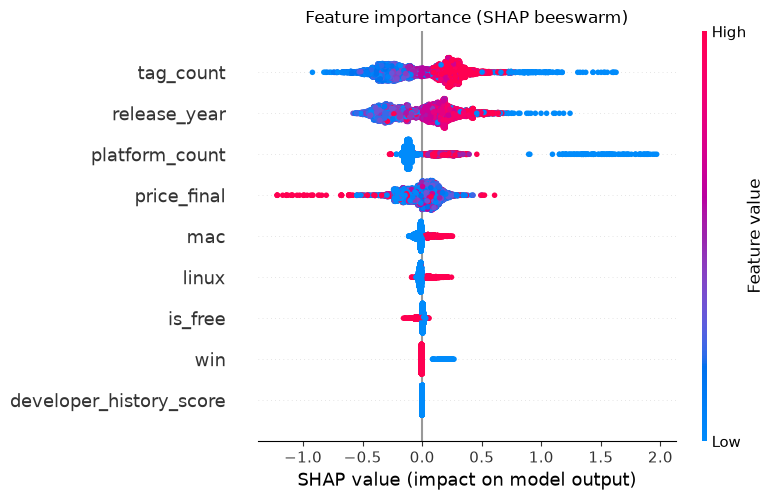

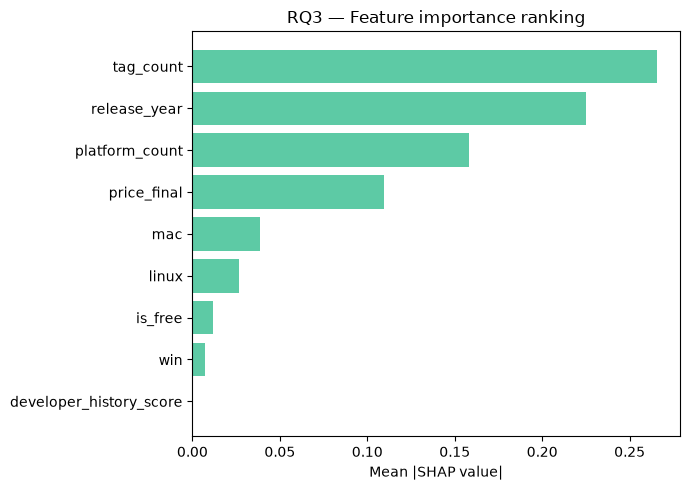

                feature  mean_shap
              tag_count   0.265518
           release_year   0.224950
         platform_count   0.157982
            price_final   0.109774
                    mac   0.038877
                  linux   0.026474
                is_free   0.011643
                    win   0.007152
developer_history_score   0.000000


In [18]:
print("Computing SHAP values... ... ...")
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# For binary classification shap_values is [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Summary plot 
plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_test, feature_names=TAB_FEATURES, show=False)
plt.title("Feature importance (SHAP beeswarm)")
plt.tight_layout()
plt.savefig("opt/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Mean absolute SHAP 
mean_shap = np.abs(sv).mean(axis=0)
imp_df = (
    pd.DataFrame({"feature": TAB_FEATURES, "mean_shap": mean_shap})
    .sort_values("mean_shap", ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df["feature"], imp_df["mean_shap"], color="#5DCAA5")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("RQ3 — Feature importance ranking")
plt.tight_layout()
plt.savefig("opt/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(imp_df.sort_values("mean_shap", ascending=False).to_string(index=False))



# 09). Table - Final Rsult

In [19]:
print("\n" + "=" * 52)
print("  RESULTS SUMMARY")
print("=" * 52)
print(f"  {'Model':<30} {'Macro-F1':>8}")
print("-" * 52)
for name, f1 in sorted(results.items(), key=lambda x: x[1]):
    hit = "  ok" if f1 >= 0.80 else ""
    print(f"  {name:<30} {f1:>8.4f}{hit}")
print("=" * 52)
print("  ok = meets macro-F1 ≥ 0.80 target\n")

results_df = pd.DataFrame(
    [{"model": k, "macro_f1": v} for k, v in results.items()]
).sort_values("macro_f1", ascending=False)

results_df.to_csv("opt/results_summary.csv", index=False)
print("Saved → results_summary.csv: ok")
print("Saved → shap_beeswarm.png: ok")
print("Saved → feature_importance.png: ok")
print("Saved → genre_f1.png: ok")


  RESULTS SUMMARY
  Model                          Macro-F1
----------------------------------------------------
  Logistic Regression              0.4226
  Random Forest                    0.4431
  XGBoost                          0.4514
  LightGBM                         0.4581
  Tabular MLP                      0.5520
  Fusion Model                     0.5974
  ok = meets macro-F1 ≥ 0.80 target

Saved → results_summary.csv: ok
Saved → shap_beeswarm.png: ok
Saved → feature_importance.png: ok
Saved → genre_f1.png: ok


# 10).Evaluation and Results

## 10.1 Experimental Setup
### 10.1.1 Train/ Validate/ Test (70,15,15)
### 10.1.2 Evaluation Metrics

In [20]:
# 10.1.1 TRAIN / VALIDATION / TEST SPLIT

print("Train / Validation / Test Split")

split_sizes = {
    "Train": len(train_df),
    "Validation": len(val_df),
    "Test": len(test_df)
}

total_samples = sum(split_sizes.values())

for name, size in split_sizes.items():
    print(
        f"{name:12s}: {size:6,d} "
        f"({size / total_samples:.2%})"
    )

# Safety checks
assert len(train_df) == len(y_train)
assert len(val_df) == len(y_val)
assert len(test_df) == len(y_test)

assert (
    len(train_df)
    + len(val_df)
    + len(test_df)
    == len(df)
)

print("\nSplit verified ")

Train / Validation / Test Split
Train       : 35,610 (70.00%)
Validation  :  7,631 (15.00%)
Test        :  7,631 (15.00%)

Split verified 


In [21]:
# 10.1.2 EVALUATION METRICS

print("Evaluation Metrics")

evaluation_metrics = {
    "Accuracy":
        "Overall proportion of correctly classified games.",

    "Precision":
        "Proportion of predicted successful games that are actually successful.",

    "Recall":
        "Proportion of actually successful games correctly identified.",

    "Macro-F1":
        "Mean F1-score across the two classes, giving each class equal weight.",

    "Weighted-F1":
        "F1-score averaged according to the number of samples in each class."
}

for metric, description in evaluation_metrics.items():
    print(f"{metric:12s}: {description}")

print("\nPrimary comparison metric: Macro-F1")

Evaluation Metrics
Accuracy    : Overall proportion of correctly classified games.
Precision   : Proportion of predicted successful games that are actually successful.
Recall      : Proportion of actually successful games correctly identified.
Macro-F1    : Mean F1-score across the two classes, giving each class equal weight.
Weighted-F1 : F1-score averaged according to the number of samples in each class.

Primary comparison metric: Macro-F1


## 10.2 Baseline Results - Tabular Only
### 10.2.1 Random Forest, LightBGM, Logistic Regression
### 10.2.2 Yes/ No can metadata alone predict success?

In [22]:
# 10.2.1 EXISTING TABULAR BASELINE RESULTS

baseline_names = [
    "Random Forest",
    "LightGBM",
    "Logistic Regression"
]

missing_baselines = [
    name
    for name in baseline_names
    if name not in results
]

if missing_baselines:
    raise RuntimeError(
        "Existing baseline results are missing: "
        + ", ".join(missing_baselines)
        + ". Run the original baseline cells before this section."
    )

baseline_results = pd.DataFrame({
    "Model": baseline_names,
    "Macro-F1": [
        results[name]
        for name in baseline_names
    ]
})

display(
    baseline_results.style.format({
        "Macro-F1": "{:.4f}"
    })
)

,Model,Macro-F1
0,Random Forest,0.4431
1,LightGBM,0.4581
2,Logistic Regression,0.4226


In [23]:
# 10.2.2 CAN METADATA ALONE PREDICT SUCCESS?

# Majority-class baseline
majority_class = (
    np.bincount(y_train).argmax()
)

majority_predictions = np.full(
    len(y_test),
    majority_class
)

majority_macro_f1 = f1_score(
    y_test,
    majority_predictions,
    average="macro"
)

best_baseline_f1 = baseline_results["Macro-F1"].max()

metadata_signal = (
    best_baseline_f1 > majority_macro_f1
)

print("Metadata-only predictive-signal check")

print(
    f"Majority-class Macro-F1 : "
    f"{majority_macro_f1:.4f}"
)

print(
    f"Best metadata model F1   : "
    f"{best_baseline_f1:.4f}"
)

print(
    "\nMetadata alone provides "
    f"a measurable predictive signal: "
    f"{'YES' if metadata_signal else 'NO'}"
)

Metadata-only predictive-signal check
Majority-class Macro-F1 : 0.4177
Best metadata model F1   : 0.4581

Metadata alone provides a measurable predictive signal: YES


# 10.3	BERT – Only Model Results
### 10.3.1 Description Only Vs description + tags


In [24]:
# 10.3.1 BERT-ONLY — PREPARE TEXT FOR BOTH VARIANTS

required_base_columns = [
    "app_id",
    "description",
    "tags"
]

for split_name, split in {
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df
}.items():

    missing = [
        col
        for col in required_base_columns
        if col not in split.columns
    ]

    if missing:
        raise RuntimeError(
            f"{split_name} is missing required columns: "
            + ", ".join(missing)
        )


# Prepare text variants inside the EXISTING splits

for split in [train_df, val_df, test_df]:

    split["description"] = (
        split["description"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    split["tags_text"] = split["tags"].apply(
        lambda x: ", ".join(map(str, x))
        if isinstance(x, list)
        else ("" if pd.isna(x) else str(x))
    )

    # Variant 1: Description only
    split["description_only_text"] = (
        split["description"]
    )

    # Variant 2: Description + Tags
    split["description_tags_text"] = (
        "Description: "
        + split["description"]
        + " Tags: "
        + split["tags_text"].str.strip()
    )


# Create aligned text tables

train_text = train_df[
    [
        "app_id",
        "description_only_text",
        "description_tags_text"
    ]
].copy()

val_text = val_df[
    [
        "app_id",
        "description_only_text",
        "description_tags_text"
    ]
].copy()

test_text = test_df[
    [
        "app_id",
        "description_only_text",
        "description_tags_text"
    ]
].copy()


# Verify alignment

assert len(train_text) == len(y_train)
assert len(val_text) == len(y_val)
assert len(test_text) == len(y_test)

assert train_text["description_only_text"].notna().all()
assert train_text["description_tags_text"].notna().all()

assert val_text["description_only_text"].notna().all()
assert val_text["description_tags_text"].notna().all()

assert test_text["description_only_text"].notna().all()
assert test_text["description_tags_text"].notna().all()


print("BERT text alignment verified ✓")
print(f"Train : {len(train_text):,}")
print(f"Val   : {len(val_text):,}")
print(f"Test  : {len(test_text):,}")

print("\nDescription-only example:")
print(train_text["description_only_text"].iloc[0][:300])

print("\nDescription + Tags example:")
print(train_text["description_tags_text"].iloc[0][:300])

BERT text alignment verified ✓
Train : 35,610
Val   : 7,631
Test  : 7,631

Description-only example:


Description + Tags example:
Description:  Tags: Adventure, LEGO, Space, Sandbox, Multiplayer


In [25]:
# BERT EMBEDDING CACHE

def get_or_create_bert_embeddings(
    variant_name,
    train_texts,
    val_texts,
    test_texts
):

    base_dir = (
        PROJECT_DIR
        / "model"
        / "bert_embeddings"
    )

    base_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    train_path = (
        base_dir
        / f"{variant_name}_train.pt"
    )

    val_path = (
        base_dir
        / f"{variant_name}_val.pt"
    )

    test_path = (
        base_dir
        / f"{variant_name}_test.pt"
    )

    # Load cached version

    if (
        train_path.exists()
        and val_path.exists()
        and test_path.exists()
    ):

        print(
            f"\nLoading cached embeddings: "
            f"{variant_name}"
        )

        return (
            torch.load(
                train_path,
                map_location="cpu"
            ).float(),

            torch.load(
                val_path,
                map_location="cpu"
            ).float(),

            torch.load(
                test_path,
                map_location="cpu"
            ).float()
        )

    print(
        f"\nGenerating embeddings: "
        f"{variant_name}"
    )

    tokenizer = DistilBertTokenizer.from_pretrained(
        CFG["bert_model"]
    )

    bert_encoder = DistilBertModel.from_pretrained(
        CFG["bert_model"]
    ).to(device)

    bert_encoder.eval()

    for parameter in bert_encoder.parameters():
        parameter.requires_grad = False

    def encode(texts):

        embeddings = []

        for start in tqdm(
            range(
                0,
                len(texts),
                CFG["batch_fusion"]
            ),
            desc=f"{variant_name} embeddings"
        ):

            batch_texts = texts[
                start:
                start + CFG["batch_fusion"]
            ]

            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=CFG["max_tokens"],
                return_tensors="pt"
            )

            encoded = {
                key: value.to(device)
                for key, value in encoded.items()
            }

            with torch.inference_mode():

                output = bert_encoder(
                    **encoded
                )

                hidden_states = (
                    output.last_hidden_state
                )

                mask = (
                    encoded["attention_mask"]
                    .unsqueeze(-1)
                    .float()
                )

                pooled = (
                    hidden_states * mask
                ).sum(dim=1) / mask.sum(
                    dim=1
                ).clamp(min=1e-9)

            embeddings.append(
                pooled.cpu().float()
            )

        return torch.cat(
            embeddings,
            dim=0
        )

    train_embeddings = encode(
        train_texts
    )

    val_embeddings = encode(
        val_texts
    )

    test_embeddings = encode(
        test_texts
    )

    torch.save(
        train_embeddings,
        train_path
    )

    torch.save(
        val_embeddings,
        val_path
    )

    torch.save(
        test_embeddings,
        test_path
    )

    del bert_encoder
    del tokenizer

    gc.collect()

    if device.type == "mps":
        torch.mps.empty_cache()

    print(
        f"{variant_name} embeddings saved ✓"
    )

    return (
        train_embeddings,
        val_embeddings,
        test_embeddings
    )

In [26]:
# DESCRIPTION-ONLY EMBEDDINGS

(
    desc_train_bert,
    desc_val_bert,
    desc_test_bert
) = get_or_create_bert_embeddings(
    "description_only",
    train_text[
        "description_only_text"
    ].tolist(),
    val_text[
        "description_only_text"
    ].tolist(),
    test_text[
        "description_only_text"
    ].tolist()
)

print("\nDescription-only embeddings")
print("Train:", tuple(desc_train_bert.shape))
print("Val  :", tuple(desc_val_bert.shape))
print("Test :", tuple(desc_test_bert.shape))


Loading cached embeddings: description_only

Description-only embeddings
Train: (35610, 768)
Val  : (7631, 768)
Test : (7631, 768)


In [27]:
# DESCRIPTION + TAGS EMBEDDINGS

(
    tags_train_bert,
    tags_val_bert,
    tags_test_bert
) = get_or_create_bert_embeddings(
    "description_tags",
    train_text[
        "description_tags_text"
    ].tolist(),
    val_text[
        "description_tags_text"
    ].tolist(),
    test_text[
        "description_tags_text"
    ].tolist()
)

print("\nDescription + Tags embeddings")
print("Train:", tuple(tags_train_bert.shape))
print("Val  :", tuple(tags_val_bert.shape))
print("Test :", tuple(tags_test_bert.shape))


Loading cached embeddings: description_tags

Description + Tags embeddings
Train: (35610, 768)
Val  : (7631, 768)
Test : (7631, 768)


In [28]:
# BERT-ONLY TRAINING FUNCTION
# MPS version — keep best model state on device

def train_bert_variant(
    train_embeddings,
    val_embeddings,
    y_train,
    y_val,
    experiment_name
):

    print("\n" + "=" * 60, flush=True)
    print(experiment_name, flush=True)
    print("=" * 60, flush=True)

    epochs = CFG["epochs_fusion"]
    batch_size = CFG["batch_fusion"]

    print(
        f"epochs_fusion = {epochs}",
        flush=True
    )

    print(
        f"batch_fusion = {batch_size}",
        flush=True
    )

    # CPU tensors

    X_train_text = train_embeddings.float().cpu()
    X_val_text = val_embeddings.float().cpu()

    y_train_text = torch.from_numpy(
        np.asarray(y_train, dtype=np.float32)
    )

    # Model
    hidden_1, hidden_2 = CFG["fusion_hidden"]

    model = nn.Sequential(
        nn.Linear(
            X_train_text.shape[1],
            hidden_1
        ),
        nn.LayerNorm(hidden_1),
        nn.ReLU(),
        nn.Dropout(CFG["dropout"]),

        nn.Linear(
            hidden_1,
            hidden_2
        ),
        nn.LayerNorm(hidden_2),
        nn.ReLU(),
        nn.Dropout(CFG["dropout"]),

        nn.Linear(
            hidden_2,
            1
        )
    ).to(device)

    n_train_batches = (
        len(X_train_text) + batch_size - 1
    ) // batch_size

    n_val_batches = (
        len(X_val_text) + batch_size - 1
    ) // batch_size

    print(
        f"Training samples: {len(X_train_text):,}",
        flush=True
    )

    print(
        f"Batches per epoch: {n_train_batches:,}",
        flush=True
    )

    print(
        f"Parameters: "
        f"{sum(p.numel() for p in model.parameters()):,}",
        flush=True
    )

    print("Classifier ready", flush=True)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = AdamW(
        model.parameters(),
        lr=CFG["lr"],
        weight_decay=1e-4
    )

    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    best_val_f1 = -1.0
    best_state = None
    history = []

    # Training

    for epoch in range(1, epochs + 1):

        print(
            f"\n========== EPOCH {epoch}/{epochs} — TRAINING ==========",
            flush=True
        )

        model.train()

        running_loss = 0.0

        for batch_number, start in enumerate(
            range(
                0,
                len(X_train_text),
                batch_size
            ),
            start=1
        ):

            end = min(
                start + batch_size,
                len(X_train_text)
            )

            X_batch = X_train_text[start:end].to(device)
            y_batch = y_train_text[start:end].to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(X_batch).squeeze(1)

            loss = criterion(
                logits,
                y_batch
            )

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            del X_batch
            del y_batch
            del logits
            del loss

            if (
                batch_number == 1
                or batch_number % 100 == 0
                or batch_number == n_train_batches
            ):
                print(
                    f"Train batch "
                    f"{batch_number:,}/{n_train_batches:,}",
                    flush=True
                )

        print(
            f"Training epoch {epoch} finished",
            flush=True
        )

        scheduler.step()

        # Validation
        print(
            f"========== EPOCH {epoch}/{epochs} — VALIDATION ==========",
            flush=True
        )

        model.eval()

        validation_probabilities = []

        with torch.inference_mode():

            for start in range(
                0,
                len(X_val_text),
                batch_size
            ):

                end = min(
                    start + batch_size,
                    len(X_val_text)
                )

                X_batch = X_val_text[start:end].to(device)

                logits = model(X_batch).squeeze(1)

                probabilities = torch.sigmoid(logits)

                validation_probabilities.append(
                    probabilities.cpu()
                )

                del X_batch
                del logits
                del probabilities
                
        val_prob = torch.cat(
            validation_probabilities,
            dim=0
        ).numpy()

        val_pred = (
            val_prob >= 0.5
        ).astype(int)

        val_f1 = f1_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        )

        avg_loss = (
            running_loss / n_train_batches
        )

        history.append({
            "epoch": epoch,
            "loss": avg_loss,
            "val_macro_f1": val_f1
        })

        print(
            f"Epoch {epoch:02d} complete | "
            f"Loss {avg_loss:.4f} | "
            f"Val Macro-F1 {val_f1:.4f}",
            flush=True
        )

        # Save best model ON DEVICE
        if val_f1 > best_val_f1:

            print(
                "Saving best model state...",
                flush=True
            )

            best_val_f1 = val_f1

            # IMPORTANT:
            # Keep the state on MPS instead of forcing
            # MPS -> CPU synchronization every epoch.
            best_state = {
                key: value.detach().clone()
                for key, value in model.state_dict().items()
            }

            print(
                "Best model updated",
                flush=True
            )

    # Restore best model
    if best_state is None:
        raise RuntimeError(
            f"No best model state was saved for "
            f"{experiment_name}."
        )

    print(
        "\nRestoring best model...",
        flush=True
    )

    model.load_state_dict(best_state)

    print(
        f"Best validation Macro-F1: "
        f"{best_val_f1:.4f}",
        flush=True
    )

    return (
        model,
        history,
        best_val_f1
    )

In [29]:
# DESCRIPTION-ONLY TRAINING

(
    bert_desc_model,
    bert_desc_history,
    bert_desc_best_val_f1
) = train_bert_variant(
    desc_train_bert,
    desc_val_bert,
    y_train,
    y_val,
    "BERT-Only — Description Only"
)


BERT-Only — Description Only
epochs_fusion = 50
batch_fusion = 32
Training samples: 35,610
Batches per epoch: 1,113
Parameters: 370,561
Classifier ready

========== EPOCH 1/50 — TRAINING ==========
Train batch 1/1,113
Train batch 100/1,113
Train batch 200/1,113
Train batch 300/1,113
Train batch 400/1,113
Train batch 500/1,113
Train batch 600/1,113
Train batch 700/1,113
Train batch 800/1,113
Train batch 900/1,113
Train batch 1,000/1,113
Train batch 1,100/1,113
Train batch 1,113/1,113
Training epoch 1 finished
========== EPOCH 1/50 — VALIDATION ==========
Epoch 01 complete | Loss 0.5840 | Val Macro-F1 0.4408
Saving best model state...
Best model updated

========== EPOCH 2/50 — TRAINING ==========
Train batch 1/1,113
Train batch 100/1,113
Train batch 200/1,113
Train batch 300/1,113
Train batch 400/1,113
Train batch 500/1,113
Train batch 600/1,113
Train batch 700/1,113
Train batch 800/1,113
Train batch 900/1,113
Train batch 1,000/1,113
Train batch 1,100/1,113
Train batch 1,113/1,113
Trai

In [31]:
# DESCRIPTION-ONLY TEST

bert_desc_model.eval()

description_test_probabilities = []

with torch.inference_mode():

    for start in range(
        0,
        len(desc_test_bert),
        CFG["batch_fusion"]
    ):

        batch = desc_test_bert[
            start:
            start + CFG["batch_fusion"]
        ].to(device)

        # Model output: [batch, 1]
        # Convert to: [batch]
        logits = bert_desc_model(
            batch
        ).squeeze(1)

        probabilities = torch.sigmoid(
            logits
        )

        description_test_probabilities.append(
            probabilities.cpu()
        )

description_test_prob = torch.cat(
    description_test_probabilities,
    dim=0
).numpy()

description_test_pred = (
    description_test_prob >= 0.5
).astype(int)

description_macro_f1 = f1_score(
    y_test,
    description_test_pred,
    average="macro",
    zero_division=0
)

results[
    "BERT-Only — Description Only"
] = description_macro_f1

print(
    f"BERT-Only — Description Only "
    f"Macro-F1: {description_macro_f1:.4f}"
)

BERT-Only — Description Only Macro-F1: 0.5541


In [32]:
# DESCRIPTION + TAGS TRAINING

(
    bert_tags_model,
    bert_tags_history,
    bert_tags_best_val_f1
) = train_bert_variant(
    tags_train_bert,
    tags_val_bert,
    y_train,
    y_val,
    "BERT-Only — Description + Tags"
)


BERT-Only — Description + Tags
epochs_fusion = 50
batch_fusion = 32
Training samples: 35,610
Batches per epoch: 1,113
Parameters: 370,561
Classifier ready

========== EPOCH 1/50 — TRAINING ==========
Train batch 1/1,113
Train batch 100/1,113
Train batch 200/1,113
Train batch 300/1,113
Train batch 400/1,113
Train batch 500/1,113
Train batch 600/1,113
Train batch 700/1,113
Train batch 800/1,113
Train batch 900/1,113
Train batch 1,000/1,113
Train batch 1,100/1,113
Train batch 1,113/1,113
Training epoch 1 finished
========== EPOCH 1/50 — VALIDATION ==========
Epoch 01 complete | Loss 0.5632 | Val Macro-F1 0.4560
Saving best model state...
Best model updated

========== EPOCH 2/50 — TRAINING ==========
Train batch 1/1,113
Train batch 100/1,113
Train batch 200/1,113
Train batch 300/1,113
Train batch 400/1,113
Train batch 500/1,113
Train batch 600/1,113
Train batch 700/1,113
Train batch 800/1,113
Train batch 900/1,113
Train batch 1,000/1,113
Train batch 1,100/1,113
Train batch 1,113/1,113
Tr

In [33]:
# DESCRIPTION + TAGS TEST

bert_tags_model.eval()

description_tags_test_probabilities = []

with torch.inference_mode():

    for start in range(
        0,
        len(tags_test_bert),
        CFG["batch_fusion"]
    ):

        batch = tags_test_bert[
            start:
            start + CFG["batch_fusion"]
        ].to(device)

        # Model output: [batch, 1]
        # Convert to: [batch]
        logits = bert_tags_model(
            batch
        ).squeeze(1)

        probabilities = torch.sigmoid(
            logits
        )

        description_tags_test_probabilities.append(
            probabilities.cpu()
        )

description_tags_test_prob = torch.cat(
    description_tags_test_probabilities,
    dim=0
).numpy()

description_tags_test_pred = (
    description_tags_test_prob >= 0.5
).astype(int)

description_tags_macro_f1 = f1_score(
    y_test,
    description_tags_test_pred,
    average="macro",
    zero_division=0
)

results[
    "BERT-Only — Description + Tags"
] = description_tags_macro_f1

print(
    f"BERT-Only — Description + Tags "
    f"Macro-F1: {description_tags_macro_f1:.4f}"
)

BERT-Only — Description + Tags Macro-F1: 0.5984


In [34]:
# 10.3.1 DESCRIPTION VS DESCRIPTION + TAGS

bert_only_comparison = pd.DataFrame({
    "Model": [
        "BERT-Only — Description Only",
        "BERT-Only — Description + Tags"
    ],

    "Best Validation Macro-F1": [
        bert_desc_best_val_f1,
        bert_tags_best_val_f1
    ],

    "Test Macro-F1": [
        description_macro_f1,
        description_tags_macro_f1
    ]
})

# Difference relative to Description Only
bert_only_comparison[
    "Test Macro-F1 Difference"
] = (
    bert_only_comparison["Test Macro-F1"]
    - description_macro_f1
)

display(
    bert_only_comparison.style.format({
        "Best Validation Macro-F1": "{:.4f}",
        "Test Macro-F1": "{:.4f}",
        "Test Macro-F1 Difference": "{:+.4f}"
    })
)

,Model,Best Validation Macro-F1,Test Macro-F1,Test Macro-F1 Difference
0,BERT-Only — Description Only,0.5573,0.5541,+0.0000
1,BERT-Only — Description + Tags,0.6025,0.5984,+0.0442


## 10.4	Fusion Model Results
### 10.4.1	Side-by-side comparison table: Baseline vs BERT-only vs Fusion
### 10.4.2	Does BERT significantly improve over metadata-only?

In [35]:
# 10.4.1 BASELINE VS BERT-ONLY VS FUSION

fusion_key = next(
    (
        key
        for key in results.keys()
        if "fusion" in key.lower()
    ),
    None
)

if fusion_key is None:
    raise RuntimeError(
        "No existing Fusion Model result was found in `results`. "
        "Run the previously created Fusion Model experiment first; "
        "this section does not recreate it."
    )

comparison_models = [
    "Random Forest",
    "LightGBM",
    "Logistic Regression",
    "BERT-Only — Description Only",
    "BERT-Only — Description + Tags",
    fusion_key
]

comparison_table = pd.DataFrame({
    "Model": comparison_models,
    "Test Macro-F1": [
        results[name]
        for name in comparison_models
    ]
})

display(
    comparison_table.style.format({
        "Test Macro-F1": "{:.4f}"
    })
)

,Model,Test Macro-F1
0,Random Forest,0.4431
1,LightGBM,0.4581
2,Logistic Regression,0.4226
3,BERT-Only — Description Only,0.5541
4,BERT-Only — Description + Tags,0.5984
5,Fusion Model,0.5974


In [36]:
# 10.4.2PAIRED BOOTSTRAP COMPARISON

baseline_predictions = {
    "Random Forest": rf.predict(X_test),
    "LightGBM": (
        lgb_model.predict(X_test) >= 0.5
    ).astype(int),
    "Logistic Regression": lr.predict(X_test)
}


def bootstrap_macro_f1_difference(
    y_true,
    predictions_a,
    predictions_b,
    n_bootstrap=2000
):

    rng = np.random.default_rng(
        CFG["seed"]
    )

    n = len(y_true)

    observed_difference = (
        f1_score(
            y_true,
            predictions_a,
            average="macro"
        )
        -
        f1_score(
            y_true,
            predictions_b,
            average="macro"
        )
    )

    bootstrap_differences = np.empty(
        n_bootstrap
    )

    for i in range(n_bootstrap):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        bootstrap_y = y_true[
            indices
        ]

        bootstrap_a = predictions_a[
            indices
        ]

        bootstrap_b = predictions_b[
            indices
        ]

        bootstrap_differences[i] = (
            f1_score(
                bootstrap_y,
                bootstrap_a,
                average="macro"
            )
            -
            f1_score(
                bootstrap_y,
                bootstrap_b,
                average="macro"
            )
        )

    lower = np.percentile(
        bootstrap_differences,
        2.5
    )

    upper = np.percentile(
        bootstrap_differences,
        97.5
    )

    return (
        observed_difference,
        lower,
        upper
    )


bert_predictions = {
    "BERT-Only — Description":
        description_test_pred,

    "BERT-Only — Description + Tags":
        description_tags_test_pred
}

significance_rows = []

for bert_name, bert_pred in bert_predictions.items():

    for baseline_name, baseline_pred in (
        baseline_predictions.items()
    ):

        difference, lower, upper = (
            bootstrap_macro_f1_difference(
                y_test,
                bert_pred,
                baseline_pred
            )
        )

        significance_rows.append({
            "BERT Model": bert_name,
            "Metadata Model": baseline_name,
            "Δ Macro-F1 (BERT - Metadata)": difference,
            "95% CI Lower": lower,
            "95% CI Upper": upper,
            "CI Excludes 0": (
                lower > 0 or upper < 0
            )
        })

bert_significance = pd.DataFrame(
    significance_rows
)

display(
    bert_significance.style.format({
        "Δ Macro-F1 (BERT - Metadata)": "{:+.4f}",
        "95% CI Lower": "{:+.4f}",
        "95% CI Upper": "{:+.4f}"
    })
)

,BERT Model,Metadata Model,Δ Macro-F1 (BERT - Metadata),95% CI Lower,95% CI Upper,CI Excludes 0
0,BERT-Only — Description,Random Forest,+0.1110,+0.0978,+0.1251,True
1,BERT-Only — Description,LightGBM,+0.0960,+0.0817,+0.1108,True
2,BERT-Only — Description,Logistic Regression,+0.1316,+0.1197,+0.1442,True
3,BERT-Only — Description + Tags,Random Forest,+0.1553,+0.1406,+0.1692,True
4,BERT-Only — Description + Tags,LightGBM,+0.1403,+0.1248,+0.1554,True
5,BERT-Only — Description + Tags,Logistic Regression,+0.1758,+0.1629,+0.1881,True


## 10.5	Feature Importance Analysis
### 10.5.1	LightGBM feature importances
### 10.5.2	SHAP value for top tabular features


LightGBM Feature Importance


,Feature,Gain
0,tag_count,10185.403420
1,price_final,8362.210283
2,release_year,8148.876587
3,platform_count,4462.421720
4,mac,1207.690568
5,linux,498.945590
6,win,430.451505
7,is_free,391.907277
8,developer_history_score,0.000000


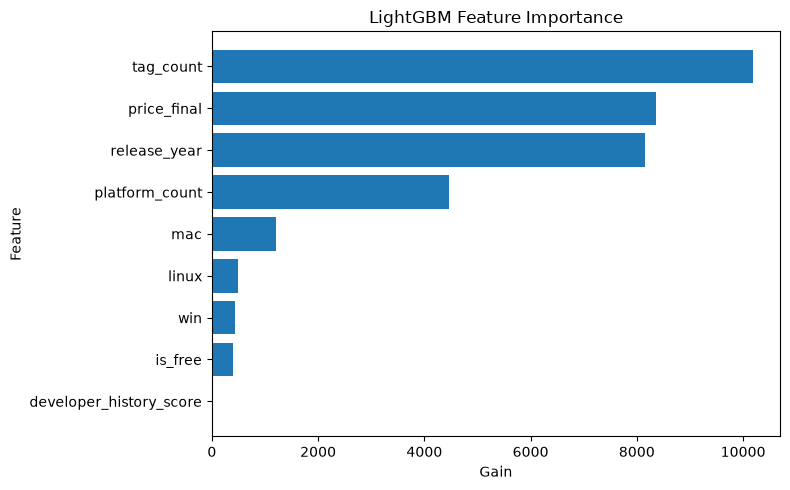

Saved: /Users/bankai/Desktop/stm/opt/feature_importance.png


In [37]:
# 10.5.1 LIGHTGBM FEATURE IMPORTANCE

lgb_importance = pd.DataFrame({
    "Feature": TAB_FEATURES,
    "Gain": lgb_model.feature_importance(
        importance_type="gain"
    )
})

lgb_importance = (
    lgb_importance
    .sort_values(
        "Gain",
        ascending=False
    )
    .reset_index(drop=True)
)

print("LightGBM Feature Importance")
display(lgb_importance)

# LIGHTGBM feature importance plot

importance_plot = (
    lgb_importance
    .sort_values("Gain")
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    importance_plot["Feature"],
    importance_plot["Gain"]
)

plt.xlabel("Gain")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance")

plt.tight_layout()

importance_path = (
    PROJECT_DIR
    / "opt"
    / "feature_importance.png"
)

plt.savefig(
    importance_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    importance_path
)

In [38]:
# 10.5.2 SHAP VALUES

# Using a bounded test sample to keep SHAP computation manageable
SHAP_SAMPLE_SIZE = min(
    2000,
    len(X_test)
)

X_shap = X_test[
    :SHAP_SAMPLE_SIZE
]

explainer = shap.TreeExplainer(
    lgb_model
)

shap_values = explainer(
    X_shap
)

# Mean absolute SHAP contribution
mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": TAB_FEATURES,
    "Mean |SHAP|": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top SHAP Features")
display(
    shap_importance.head(5)
)

Top SHAP Features


,Feature,Mean |SHAP|
0,tag_count,0.268364
1,release_year,0.228835
2,platform_count,0.158561
3,price_final,0.109645
4,mac,0.039919


## 10.6	Genre-Specific Analysis
### 10.6.1	Results Broken Down by RPG – Shooter – Indie
### 10.6.2	Do important features differ across genres?


In [39]:
# 10.6.1 GENRE-SPECIFIC RESULTS

genre_text_test = (
    test_df["tags"]
    .fillna("")
    .astype(str)
    .str.lower()
)

genre_masks = {
    "RPG": genre_text_test.str.contains(
        "rpg",
        regex=False
    ),

    "Shooter": genre_text_test.str.contains(
        "shooter",
        regex=False
    ),

    "Indie": genre_text_test.str.contains(
        "indie",
        regex=False
    )
}

# Existing LightGBM predictions
lgb_test_prob = (
    lgb_model.predict(X_test)
)

lgb_test_pred = (
    lgb_test_prob >= 0.5
).astype(int)

genre_rows = []

for genre, mask in genre_masks.items():

    indices = np.flatnonzero(
        mask.to_numpy()
    )

    if len(indices) == 0:
        continue

    y_genre = y_test[
        indices
    ]

    pred_genre = lgb_test_pred[
        indices
    ]

    if len(np.unique(y_genre)) < 2:

        macro_f1 = np.nan

    else:

        macro_f1 = f1_score(
            y_genre,
            pred_genre,
            average="macro"
        )

    genre_rows.append({
        "Genre": genre,
        "N": len(indices),
        "Macro-F1": macro_f1
    })

genre_results = pd.DataFrame(
    genre_rows
)

display(
    genre_results.style.format({
        "Macro-F1": "{:.4f}"
    })
)

,Genre,N,Macro-F1
0,RPG,1624,0.4422
1,Shooter,765,0.4483
2,Indie,4215,0.4651


In [40]:
# 10.6.2 GENRE-SPECIFIC FEATURE IMPORTANCE

genre_feature_importance = {}

# Same LightGBM configuration already used above
genre_num_boost_round = int(
    getattr(
        lgb_model,
        "best_iteration",
        0
    )
    or 500
)

for genre, train_mask in {
    "RPG": (
        train_df["tags"]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.contains(
            "rpg",
            regex=False
        )
    ),

    "Shooter": (
        train_df["tags"]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.contains(
            "shooter",
            regex=False
        )
    ),

    "Indie": (
        train_df["tags"]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.contains(
            "indie",
            regex=False
        )
    )
}.items():

    train_indices = np.flatnonzero(
        train_mask.to_numpy()
    )

    if len(train_indices) < 100:
        print(
            f"{genre}: insufficient training "
            f"samples ({len(train_indices)}). Skipped."
        )
        continue

    y_genre_train = y_train[
        train_indices
    ]

    if len(np.unique(y_genre_train)) < 2:
        print(
            f"{genre}: only one target class "
            "in training subset. Skipped."
        )
        continue

    X_genre_train = X_train[
        train_indices
    ]

    genre_dataset = lgb.Dataset(
        X_genre_train,
        label=y_genre_train,
        feature_name=TAB_FEATURES
    )

    genre_model = lgb.train(
        lgb_params,
        genre_dataset,
        num_boost_round=genre_num_boost_round
    )

    importance = pd.DataFrame({
        "Feature": TAB_FEATURES,
        "Gain": genre_model.feature_importance(
            importance_type="gain"
        )
    })

    importance = (
        importance
        .sort_values(
            "Gain",
            ascending=False
        )
        .reset_index(drop=True)
    )

    genre_feature_importance[
        genre
    ] = importance

print("Top features by genre")

for genre, importance in (
    genre_feature_importance.items()
):

    print(f"\n{genre}")

    display(
        importance.head(5)
    )

Top features by genre

RPG


,Feature,Gain
0,price_final,3868.657117
1,tag_count,3383.440567
2,release_year,2933.515867
3,platform_count,617.153780
4,win,384.269930



Shooter


,Feature,Gain
0,price_final,2559.671136
1,tag_count,1815.488155
2,release_year,1774.065048
3,platform_count,480.548680
4,linux,284.419721



Indie


,Feature,Gain
0,release_year,8066.604566
1,price_final,4876.678083
2,tag_count,4600.383171
3,platform_count,3648.515570
4,mac,620.528545


## 10.7	Ablation Study
### 10.7.1	Remove tabular branch 
### 10.7.2	Remove BERT Branch 


In [41]:
# 10.7.1 REMOVE TABULAR BRANCH

if "BERT-Only — Description + Tags" not in results:
    raise RuntimeError(
        "BERT-Only — Description + Tags result is missing. "
        "Run Section 1.3 before the ablation study."
    )

fusion_key = next(
    (
        key
        for key in results
        if "fusion" in key.lower()
    ),
    None
)

if fusion_key is None:
    raise RuntimeError(
        "No Fusion Model result found in `results`. "
        "Run the existing Fusion Model experiment before "
        "the ablation study."
    )

remove_tabular_result = pd.DataFrame({
    "Configuration": [
        "Full Fusion",
        "Without Tabular Branch"
    ],
    "Model": [
        fusion_key,
        "BERT-Only — Description + Tags"
    ],
    "Test Macro-F1": [
        results[fusion_key],
        results["BERT-Only — Description + Tags"]
    ]
})

display(
    remove_tabular_result.style.format({
        "Test Macro-F1": "{:.4f}"
    })
)

print(
    "\nBERT-only (without tabular branch) Test Macro-F1:",
    f"{results['BERT-Only — Description + Tags']:.4f}"
)

,Configuration,Model,Test Macro-F1
0,Full Fusion,Fusion Model,0.5974
1,Without Tabular Branch,BERT-Only — Description + Tags,0.5984



BERT-only (without tabular branch) Test Macro-F1: 0.5984


In [42]:
# 10.7 ABLATION STUDY

# Existing full fusion result
fusion_key = next(
    (
        key
        for key in results.keys()
        if "fusion" in key.lower()
    ),
    None
)

if fusion_key is None:
    raise RuntimeError(
        "Existing Fusion result not found in `results`."
    )

# Existing tabular-only neural model
if "Tabular MLP" in results:

    tabular_ablation_name = (
        "Tabular MLP"
    )

else:

    # Fall back to an already-trained classical
    # metadata-only model rather than retraining.
    tabular_ablation_name = (
        "LightGBM"
    )

ablation_results = pd.DataFrame({
    "Configuration": [
        "Full Fusion",
        "Remove Tabular Branch",
        "Remove BERT Branch"
    ],

    "Model Used": [
        fusion_key,
        "BERT-Only — Description + Tags",
        tabular_ablation_name
    ],

    "Test Macro-F1": [
        results[fusion_key],
        results[
            "BERT-Only — Description + Tags"
        ],
        results[
            tabular_ablation_name
        ]
    ]
})

display(
    ablation_results.style.format({
        "Test Macro-F1": "{:.4f}"
    })
)

,Configuration,Model Used,Test Macro-F1
0,Full Fusion,Fusion Model,0.5974
1,Remove Tabular Branch,BERT-Only — Description + Tags,0.5984
2,Remove BERT Branch,Tabular MLP,0.5520


## 10.8 Discussion

In [43]:
print("=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)


# 1. Dataset / Split
print("\n1. Dataset / Split")

print(
    f"Train: {len(y_train):,} | "
    f"Validation: {len(y_val):,} | "
    f"Test: {len(y_test):,}"
)



# 2. Metadata-only baselines
print("\n2. Metadata-only baselines")

baseline_names = [
    "Random Forest",
    "LightGBM",
    "Logistic Regression",
    "XGBoost",
    "Tabular MLP"
]

for name in baseline_names:

    if name in results:

        print(
            f"{name:22s}: "
            f"{results[name]:.4f}"
        )

    else:

        print(
            f"{name:22s}: NOT AVAILABLE"
        )


# 3. BERT-only
print("\n3. BERT-only")

bert_names = [
    (
        "Description Only",
        "BERT-Only — Description Only"
    ),
    (
        "Description + Tags",
        "BERT-Only — Description + Tags"
    )
]

for label, result_key in bert_names:

    if result_key in results:

        print(
            f"{label:30s}: "
            f"{results[result_key]:.4f}"
        )

    else:

        print(
            f"{label:30s}: NOT AVAILABLE"
        )


# 4. Fusion
print("\n4. Fusion")

fusion_key = next(
    (
        key
        for key in results.keys()
        if "fusion" in key.lower()
    ),
    None
)

if fusion_key is not None:

    print(
        f"{fusion_key:30s}: "
        f"{results[fusion_key]:.4f}"
    )

else:

    print(
        "Fusion Model: NOT AVAILABLE"
    )


# 5. Metadata predictive signal
print("\n5. Metadata predictive signal")

if "metadata_signal" in globals():

    print(
        "Better than majority baseline: "
        f"{'YES' if metadata_signal else 'NO'}"
    )

else:

    print(
        "Metadata signal analysis: NOT AVAILABLE"
    )


# 6. Genre-specific results
print("\n6. Genre-specific results")

if "genre_results" in globals():

    display(
        genre_results
    )

else:

    print(
        "Genre-specific results: NOT AVAILABLE"
    )


# 7. Ablation
print("\n7. Ablation")

if "ablation_results" in globals():

    display(
        ablation_results
    )

else:

    print(
        "Ablation results: NOT AVAILABLE"
    )

EXPERIMENT SUMMARY

1. Dataset / Split
Train: 35,610 | Validation: 7,631 | Test: 7,631

2. Metadata-only baselines
Random Forest         : 0.4431
LightGBM              : 0.4581
Logistic Regression   : 0.4226
XGBoost               : 0.4514
Tabular MLP           : 0.5520

3. BERT-only
Description Only              : 0.5541
Description + Tags            : 0.5984

4. Fusion
Fusion Model                  : 0.5974

5. Metadata predictive signal
Better than majority baseline: YES

6. Genre-specific results


,Genre,N,Macro-F1
0,RPG,1624,0.442152
1,Shooter,765,0.448295
2,Indie,4215,0.465140



7. Ablation


,Configuration,Model Used,Test Macro-F1
0,Full Fusion,Fusion Model,0.597358
1,Remove Tabular Branch,BERT-Only — Description + Tags,0.598399
2,Remove BERT Branch,Tabular MLP,0.551977
